# VAR(1, 2) で学習・予測を行う。

In [1]:
import platform                  # Python 3.9.16
import sys

import numpy             as np   # Numpy 1.23.2
import pandas            as pd   # Pandas 2.0.3
import matplotlib.pyplot as plt
%matplotlib inline
# print(plt.rcParams.keys())
plt.rcParams.update({
    'font.size'     : 16,
    'axes.grid'     : True,
    'grid.linestyle': '--',
    'lines.linewidth': 2,
})
from matplotlib.colors import LogNorm
import seaborn as sns

# from pathlib import Path
# savedir = "../reports/figures/1217_VAR_best/"
# Path(savedir).mkdir(parents=True, exist_ok=True)
# modeldir = "../models/1217_VAR_best/"
# Path(modeldir).mkdir(parents=True, exist_ok=True)

import statsmodels.api  as sm    # Statsmodels 0.14.0

print(f"Python Platform: {platform.platform()}")
print(f"Python {sys.version}")
print(f"Pandas {pd.__version__}")
print(f"Numpy {np.__version__}")
print()
print(f"Statsmodels {sm.__version__}")
print()

Python Platform: macOS-13.4-arm64-arm-64bit
Python 3.9.16 | packaged by conda-forge | (main, Feb  1 2023, 21:38:11) 
[Clang 14.0.6 ]
Pandas 2.0.3
Numpy 1.23.2

Statsmodels 0.14.0



In [2]:
coef_raw = pd.read_csv("./coef.csv")

# make column of name = "letter(n, m)"
coef = coef_raw.iloc[:195, :]

coef["coef"] = coef["letter"] + "(" + coef["n"].astype(str) + ", " + coef["m"].astype(str) + ")"

coef_dfT = coef.loc[:, "2004.75":"2019.50"]

coef_dfT.index = coef["coef"]

coef_df = coef_dfT.T

# インデックスの範囲を設定（2004年から2019年まで3ヶ月ごと）
# start_date, end_date = '2004-10-01', '2019-07-01'
# coef_df.index = pd.date_range(start=start_date, end=end_date, freq="QS")

coef_df.index.name = "YEAR"
coef_df.index = coef_df.index.astype(float)

# display(coef_df)

/var/folders/m6/3_6_32s90qdf_nhdhwt9413w0000gn/T/ipykernel_40036/2396854735.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef["coef"] = coef["letter"] + "(" + coef["n"].astype(str) + ", " + coef["m"].astype(str) + ")"


### 時間差分データの作成

In [3]:
diff0 = coef_df
diff1 = diff0.diff(1, "index").dropna()
diff2 = diff1.diff(1, "index").dropna()

diff = [diff0, diff1, diff2]

# display(diff2)

In [4]:
def create_train_test(input_df: pd.DataFrame):
    transformer_df = pd.DataFrame(index=["min_val", "max_val", "scale"], columns=input_df.columns)
    scaled_df = pd.DataFrame(index=input_df.index, columns=input_df.columns)

    for col in input_df.columns:
        min_val, max_val = input_df[col].min(), input_df[col].max()
        scale = max_val - min_val

        transformer_df.loc["min_val", col] = min_val
        transformer_df.loc["max_val", col] = max_val
        transformer_df.loc["scale",   col] = scale

        scaled_df[col] = (input_df[col] - min_val) / scale

    train_df = scaled_df.loc[       :2014.50, :]
    test_df  = scaled_df.loc[2014.75:2019.50, :]

    # train_size, test_size = len(train_df), len(test_df)

    # display(train_df)
    # display(test_df)

    return train_df, test_df, transformer_df

In [5]:
train, test, transformer, train_size, test_size = [[-1, -1, -1, -1, -1] for _ in range(5)]

for d in range(3):
    input_df = diff[d]
    train[d], test[d], transformer[d] =  create_train_test(input_df)
    train_size[d], test_size[d] = len(train[d]), len(test[d])


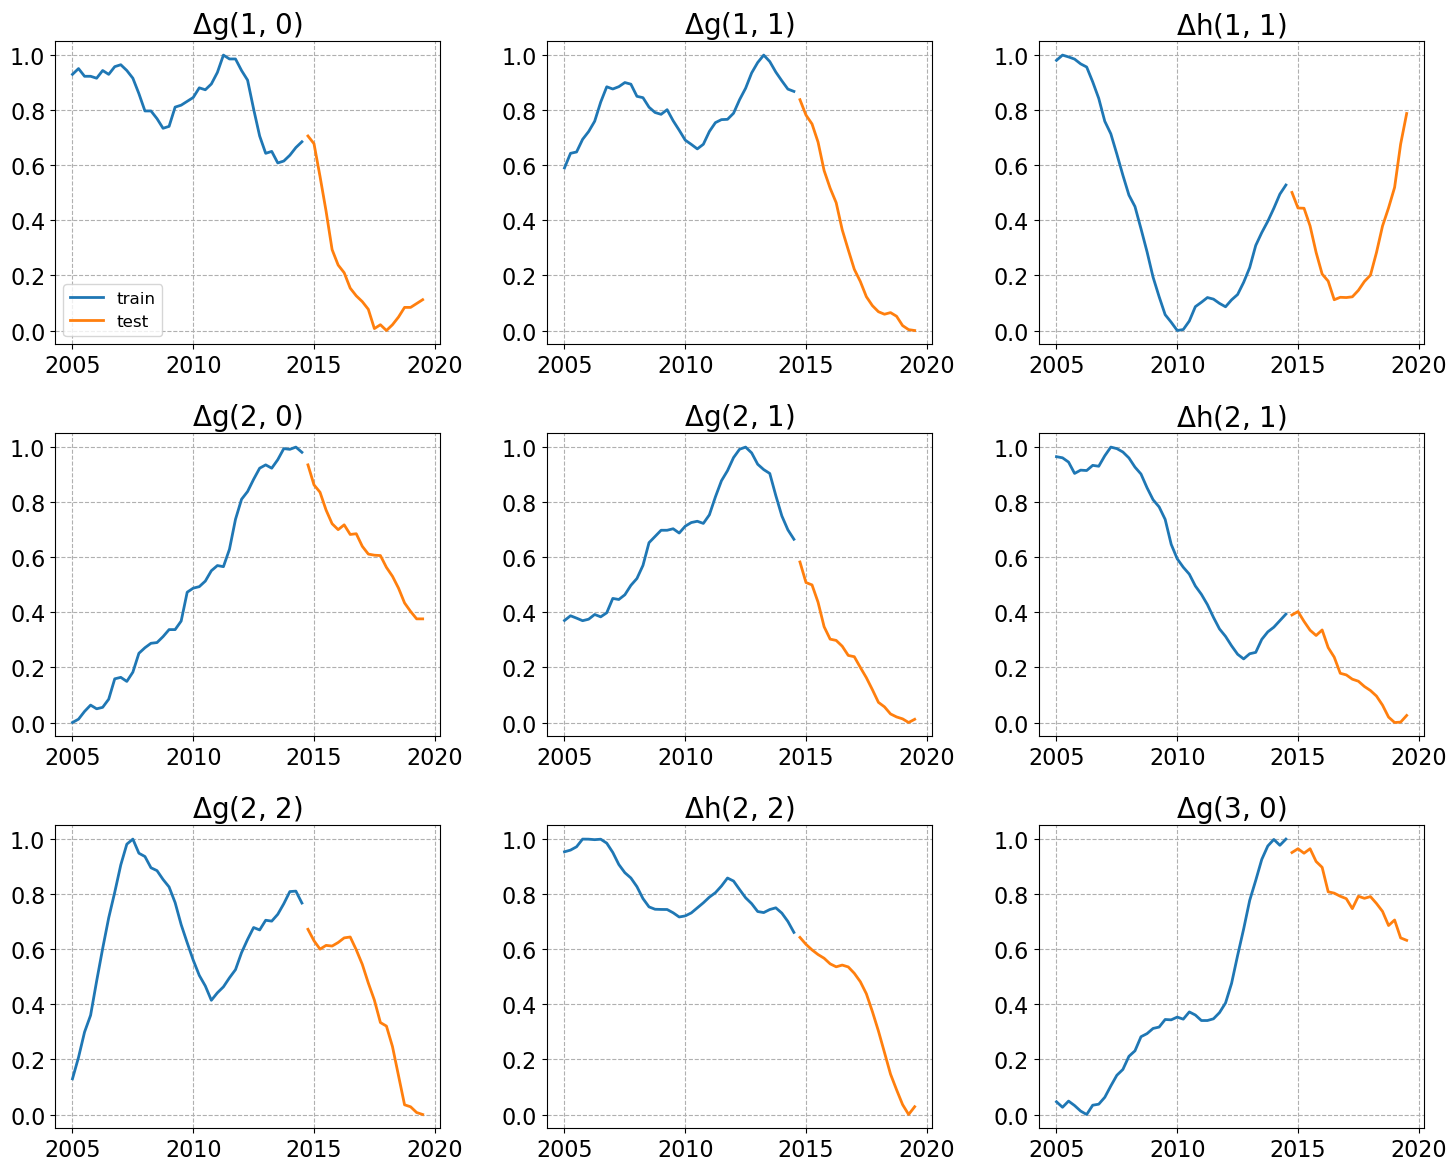

In [6]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1]

    ax.plot(train[1].index, train[1][target], label="train")
    ax.plot(test[1].index, test[1][target], label="test")

    ax.set_title(r"$\Delta$" + target, fontsize=20)


axes[0].legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.savefig("1_train_test_d1g.png")
plt.show()


# 学習・予測


In [23]:
def integrate(Y0: float, dY: np.ndarray)->np.ndarray:
    Y = np.zeros(len(dY) + 1)

    Y[0] = Y0
    for i in range(len(dY)):
        Y[i + 1] = Y[i] + dY[i]
    
    return Y[1:]

In [24]:
def get_dP(pred_test: pd.DataFrame):
    ### get dP_n(t)
    epochs = pred_test.index
    gnames = pred_test.columns

    dP = np.zeros((len(epochs), 14), dtype=float) # n==0 is dummy
    for i, epoch in enumerate(epochs):
        # print(epoch)
        for target in gnames:
            n = int(target[2:].split(",")[0])
            dP[i, n] += (n+1) * (pred_test.loc[epoch, target] - coef_df.loc[epoch, target]) * (pred_test.loc[epoch, target] - coef_df.loc[epoch, target])
    
    dP = np.delete(dP, [0, 9, 10, 11, 12, 13], axis=1) # n==0 is dummy, drop n=9, 10, 11, 12, 13
    # print(dP)
    dPsum = np.sum(dP, axis=1)
    ave = np.average(np.sqrt(dPsum))
    y10 = np.sqrt(dPsum[-1])

    return ave, y10

In [25]:
#outtype = ".eps"
outtype = ".png"

i2015data = np.loadtxt("../models/igrf2015.dat")
i2020data = np.loadtxt("../models/igrf2020.dat")

# print(i2005data[0,:])
# print(i2005data[1,:])

i2015data[1,:] = i2015data[0,:] + 5.0 * i2015data[1,:]
i2015data[1,0] = 2015.0
i2015data[1,0] = 2020.0
# print(i2015data)

i2020data[1,:] = i2020data[0,:] + 5.0 * i2020data[1,:]
i2020data[1,0] = 2020.0
i2020data[1,0] = 2025.0
# print(i2025data)

def plot_result(axis, pred_train, pred_test, coef_idx, target):

    # igrf2015 (comparison)
    axis.plot   ( i2015data[:,0],          i2015data[:,coef_idx],         color='green') # SV
    axis.scatter( i2015data[0,0],          i2015data[0,coef_idx],         color='green', label="IGRF2015", marker='*', s=200, edgecolors='black' )
    # igrf2020 (comparison)
    # axis.plot   ( i2020data[:,0],          i2020data[:,coef_idx],         color='olive') # SV
    axis.scatter( i2020data[0,0],          i2020data[0,coef_idx],         color='olive', label="IGRF2020", marker='*', s=200, edgecolors='black' )

    coef_df[target].plot(ax=axis, color='black'  , label="Original")   # Vincent data (true)

    axis.plot(pred_train.index, pred_train[target], color='red', linewidth=1) # predict (VAR(1, 2))
    pred_test[target].plot(ax=axis, color='red' , label="VAR prediction") # predict (VAR(1, 2))
   

    axis.set_ylabel("g  [nT]")
    axis.set_xticks(np.arange(2005, 2021, 5))
    axis.grid()

def plot_dg(axis, d, dg_train, dg_test, target):
    
    (diff[d] * 4**d)[target].plot(ax=axis, color='black'  , label="Original")   # Vincent data (true)
    
    axis.plot(dg_train.index, dg_train[target], color='red', linewidth=1) # predict (VAR(1, 2))
    dg_test[target].plot(ax=axis, color='red' , label="VAR prediction") # predict (VAR(1, 2))

    axis.set_ylabel(f"$\Delta^{d} g / \Delta t ^{d}$  [nT/$yr^2$]")
    axis.set_xticks(np.arange(2005, 2021, 5))
    axis.grid()

In [26]:
def draw_dP(pred_test):

    epochs = pred_test.index
    gnames = pred_test.columns

    ### get dP_n(t)

    dP = np.zeros((len(epochs), 14), dtype=float) # n==0 is dummy

    for i, epoch in enumerate(epochs):
        # print(epoch)

        for target in gnames:
            n = int(target[2:].split(",")[0])

            dP[i, n] += (n+1) * (pred_test.loc[epoch, target] - coef_df.loc[epoch, target]) * (pred_test.loc[epoch, target] - coef_df.loc[epoch, target])

    dP = np.delete(dP, [0, 9, 10, 11, 12, 13], axis=1) # n==0 is dummy, ~~n >= 11 is not used~~
    # print(dP)

    dP_df = pd.DataFrame(np.sqrt(dP), index=epochs, columns=range(1, 9))

    # print(dP_df)

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    plt.rcParams.update({
        'font.size'     : 11,
        })

    sns.heatmap(dP_df, cmap='jet', norm=LogNorm(vmin=0.01, vmax=100), ax=ax[0])
    ax[0].set_xlabel('degree (n)', fontsize=12)
    ax[0].set_ylabel('epoch (Year)\n', fontsize=12)
    ax[0].set_yticks(np.arange(1.5, len(epochs), 4), epochs[1::4])
    ax[0].set_title(r"$\sqrt{\mathrm{d} P_n} = \sqrt{\sum_m (n+1) \left[ g_\mathrm{\ TEST}^{m} - g_\mathrm{\ PRED}^{m} \right]^2}$" + "\n")
    ax[0].grid(False)

    dPsum = np.sum(dP, axis=1)


    ave = np.average(np.sqrt(dPsum))
    y10 = np.sqrt(dPsum[-1])

    # print(ave)
    # print(y10)

    ax[1].vlines(x=ave, ymin=epochs[0], ymax=epochs[-1], color="red", linestyle='--')
    ax[1].text(ave, epochs[-1], f"{ave:.2f} ", ha='right', va='bottom', fontsize=14, color='red')
    ax[1].text(y10, epochs[-1], f" {y10:.2f}", ha='left',  va='bottom', fontsize=14, color='blue')

    ax[1].plot(np.sqrt(dPsum), epochs, c='k')
    ax[1].set_xlabel(r"$\sqrt{\mathrm{d} P}$ [nT]", fontsize=12)
    ax[1].set_xscale('log')
    ax[1].set_xticks([0.1, 1, 10, 100, 1000])
    ax[1].set_ylim(epochs[-1], epochs[0])
    ax[1].set_yticks(epochs[1::4])
    ax[1].set_title(r"$\sqrt{\mathrm{d} P} = \sqrt{\sum_n \mathrm{d} P_n}$" + "\n")

    fig.tight_layout()

    return fig, ax


## VAR(1, 2)

In [27]:
p, d = 1, 2

model = sm.tsa.VAR(train[d])
results = model.fit(p)

# print(results.summary()) # VARの結果を表示 <-- does not work

/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [28]:
d2g_train = pd.DataFrame(index=train[d].index[p:], columns=train[d].columns)
for t in range(train_size[d]-p):
    d2g_train.iloc[t, :] = results.forecast(train[d].values[t:t+p], 1)

d2g_test  = pd.DataFrame(results.forecast(train[d].values[-p:], test_size[d]), index=test[d].index, columns=test[d].columns)

d1g_train = pd.DataFrame(index=train[d].index[p:], columns=train[d].columns)
d1g_test  = pd.DataFrame(index=test[d].index, columns=test[d].columns)
d0g_train = pd.DataFrame(index=train[d].index[p:], columns=train[d].columns)
d0g_test  = pd.DataFrame(index=test[d].index, columns=test[d].columns)


train0_epoch = train[d].index[p-1]
test0_epoch  = 2014.50 # = train[d].index[-1]"
for target in coef_df.columns:
    min_val, max_val, scale = transformer[d][target]
    train_result = d2g_train[target].values * scale + min_val
    test_result  = d2g_test[target].values * scale + min_val

    d2g_train[target] = train_result
    d2g_test[target]  = test_result

    # integrate
    train_result = diff[1][target].loc[train0_epoch:test0_epoch-0.25] + train_result
    test_result  = integrate(diff[1][target].loc[test0_epoch], test_result)

    d1g_train[target] = train_result
    d1g_test[target]  = test_result

    train_result = diff[0][target].loc[train0_epoch:test0_epoch-0.25] + train_result
    test_result = integrate(diff[0][target].loc[test0_epoch], test_result)

    d0g_train[target] = train_result
    d0g_test[target]  = test_result

print(get_dP(d0g_test))

(39.57560381252888, 98.32518368814264)


## magpred

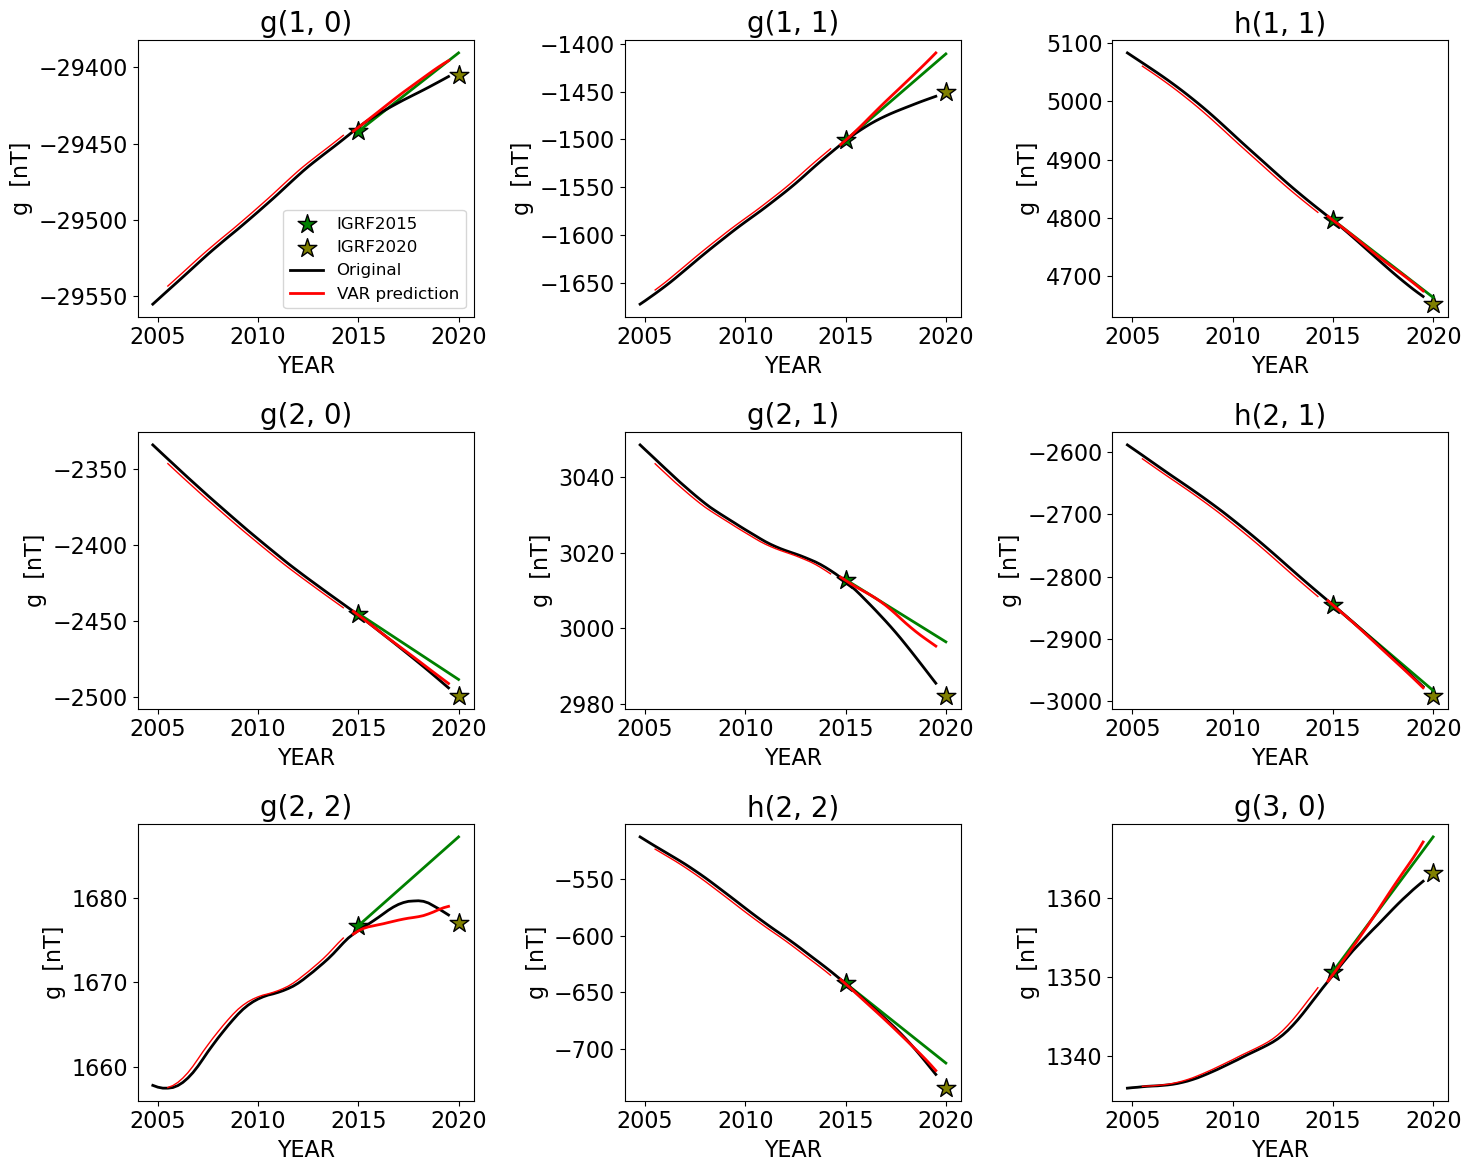

In [29]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1]
    
    plot_result(ax, d0g_train, d0g_test, idx, target)
    ax.set_title(target, fontsize=20)

axes[0].legend(loc='lower right', fontsize=12)


plt.tight_layout()
plt.savefig(savedir + f"2a_magpred_d0g_VAR1_2.png")
plt.show()


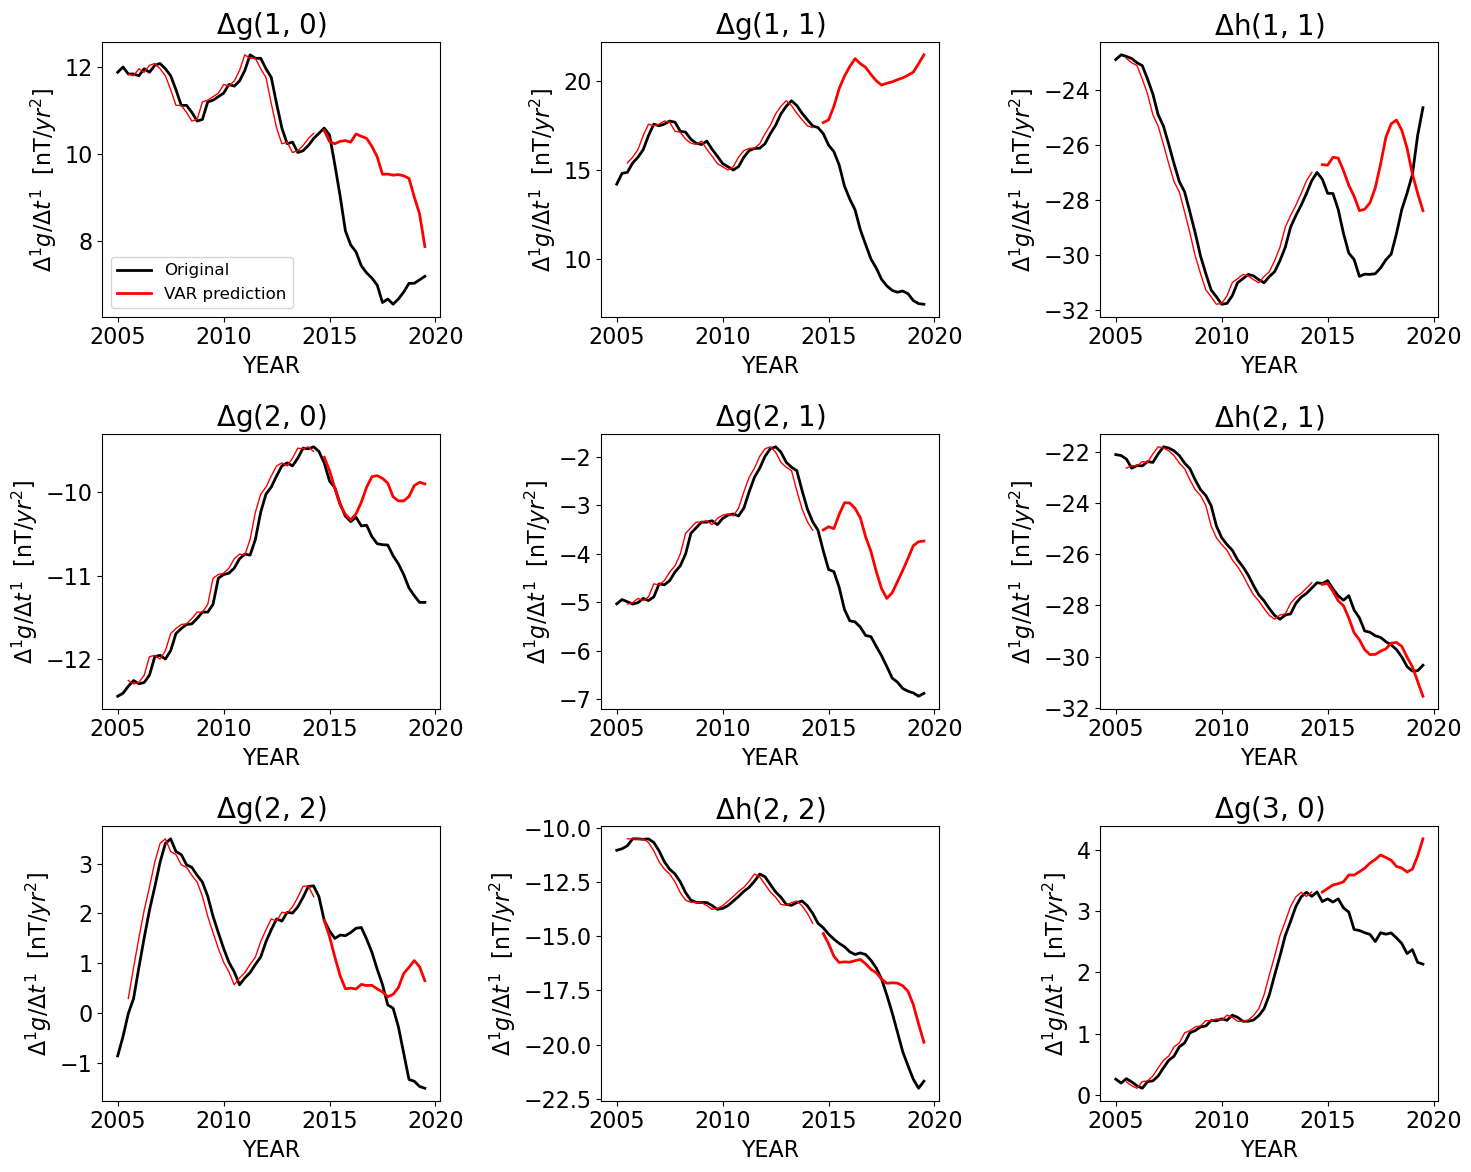

In [30]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

d1gdt_train = d1g_train * 4**1
d1gdt_test  = d1g_test  * 4**1

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1] 
    
    plot_dg(ax, 1, d1gdt_train, d1gdt_test, target)

    ax.set_title(r"$\Delta$" + target, fontsize=20)

axes[0].legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.savefig(savedir + f"2a_magpred_1g_VAR1_2.png")
plt.show()


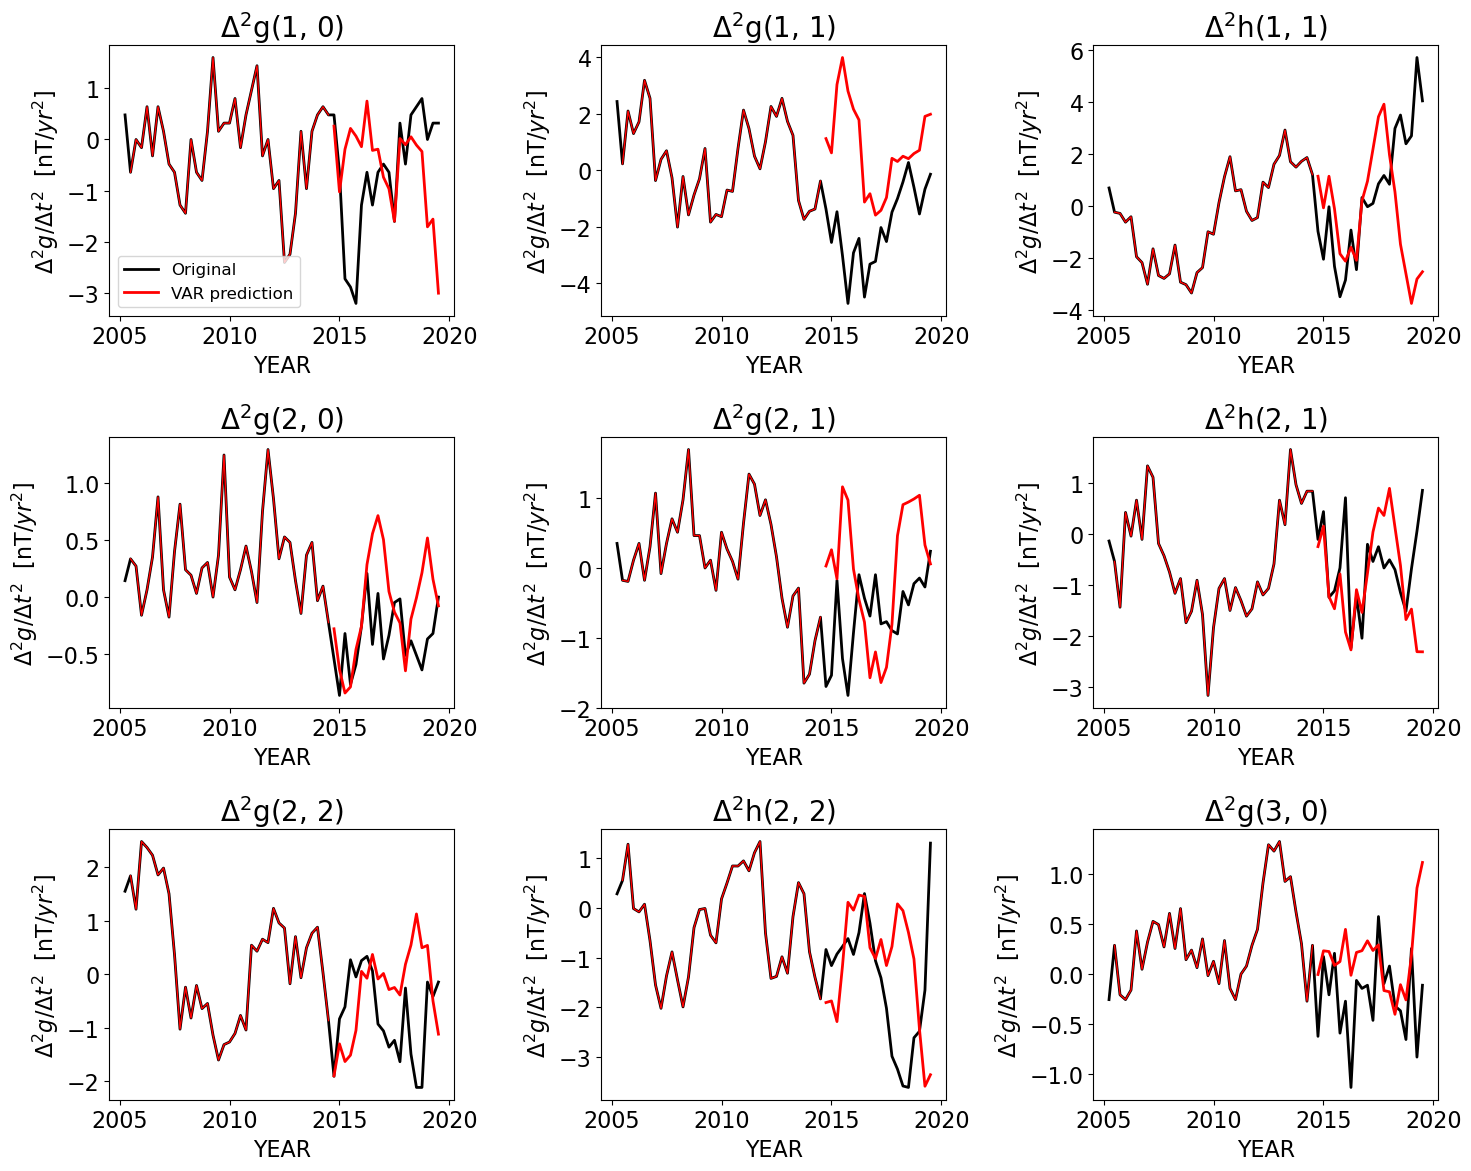

In [31]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

d2gdt_train = d2g_train * 4**2
d2gdt_test  = d2g_test  * 4**2

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1] 
    
    plot_dg(ax, 2, d2gdt_train, d2gdt_test, target)

    ax.set_title(r"$\Delta^2$" + target, fontsize=20)

axes[0].legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.savefig(savedir + f"2a_magpred_2g_VAR1_2.png")
plt.show()


## $\sqrt{dP}$

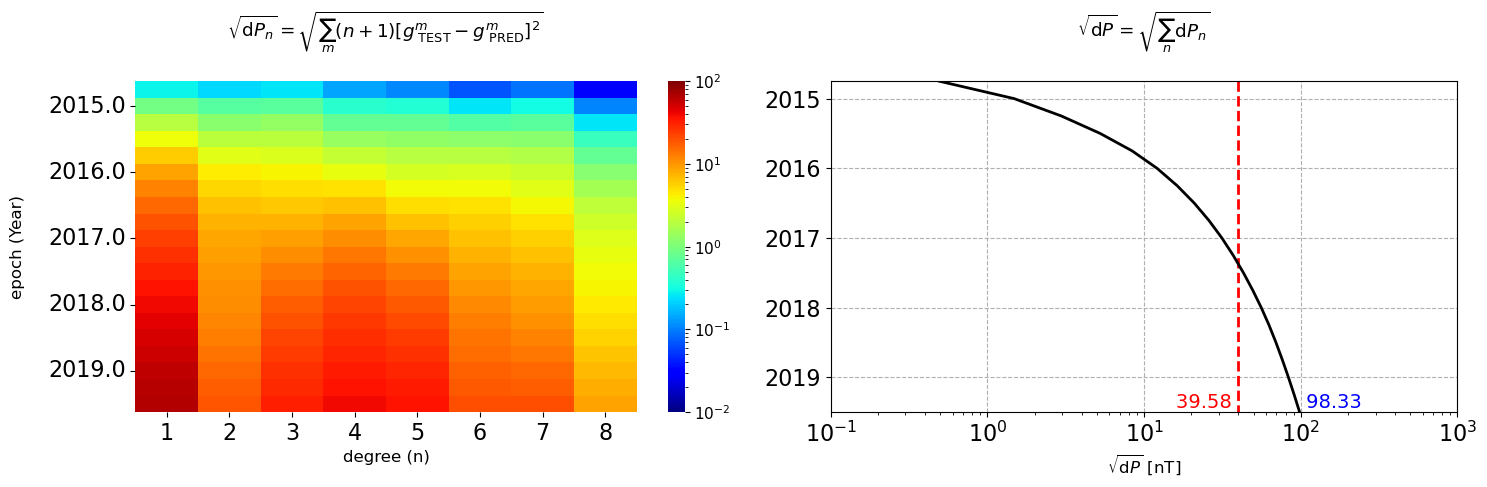

In [32]:
fig, ax = draw_dP(d0g_test)
plt.savefig(savedir + f"2b_dP_diagram_VAR1_2.png")
plt.show()

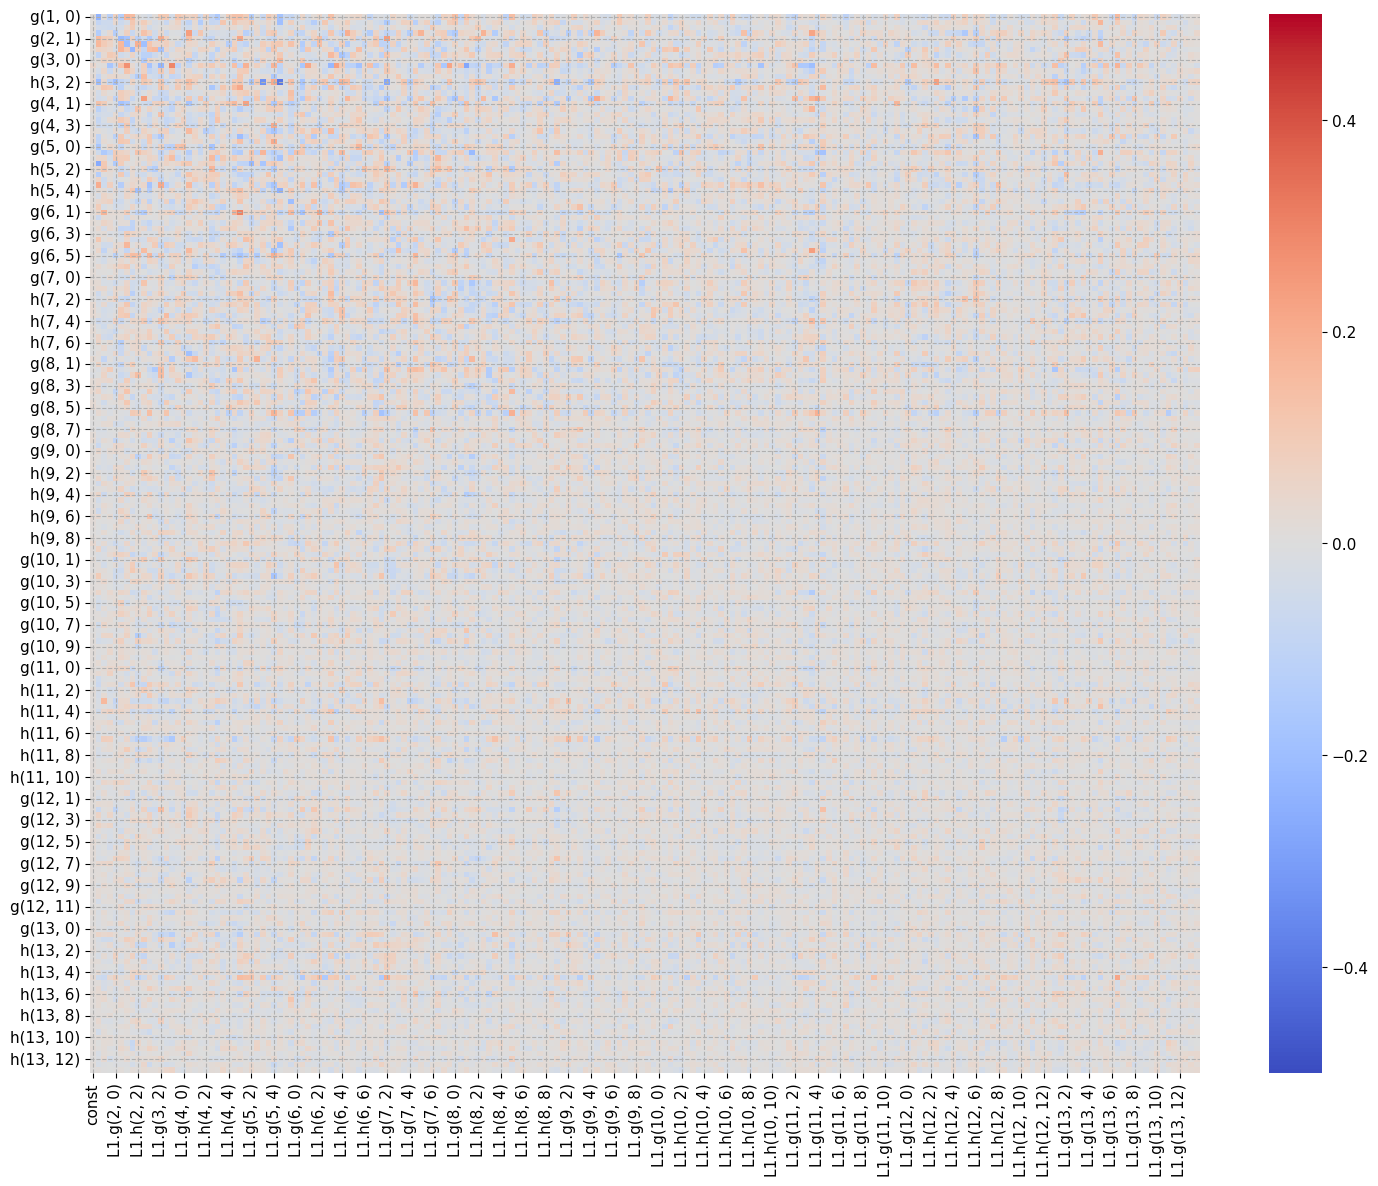

In [33]:
fig, ax = plt.subplots(figsize=(15, 12))

ax.fontdict = {"fontsize": 11}

sns.heatmap(results.params.T, cmap="coolwarm", annot=False, vmin=-0.5, vmax=0.5)
plt.tight_layout()
plt.savefig(savedir + f"2c_VAR1_2_coef.png")
plt.show()

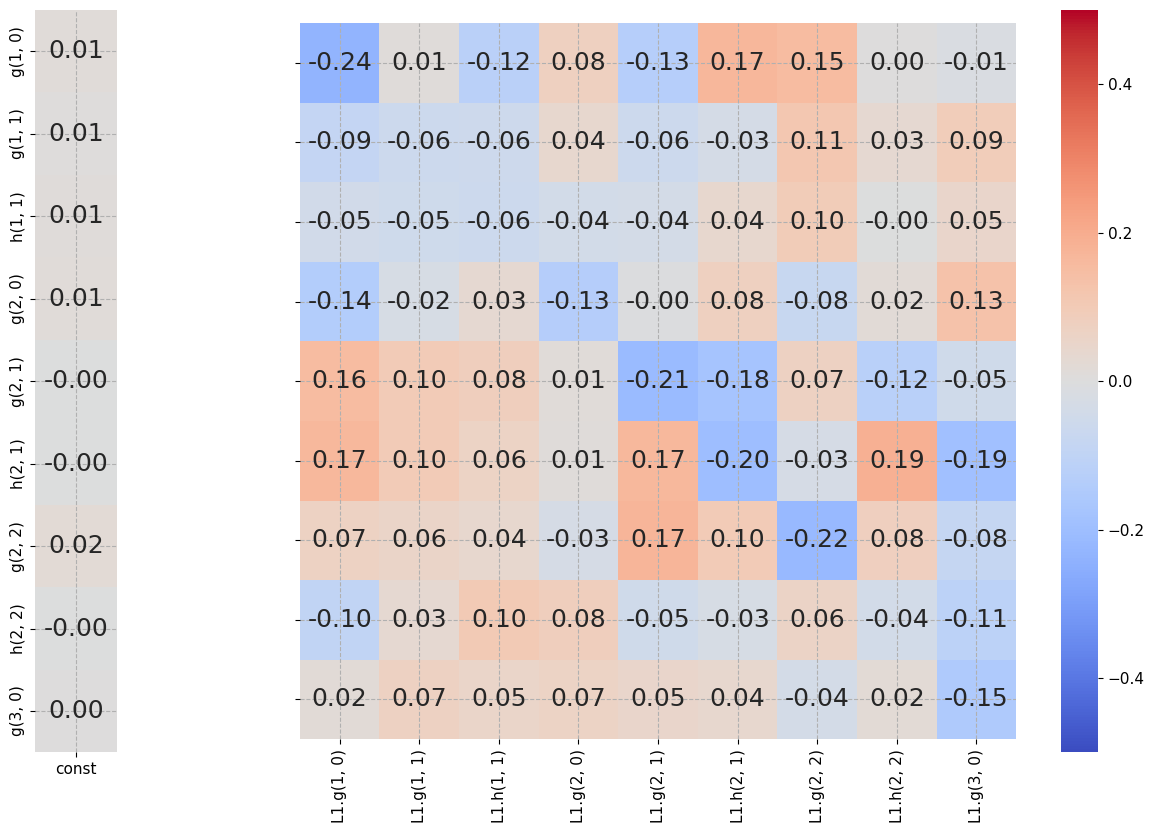

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

ax[0].fontdict = {"fontsize": 11}
ax[1].fontdict = {"fontsize": 11}

sns.heatmap(results.params.iloc[0:1, :9].T, cmap="coolwarm", 
            vmin=-0.5, vmax=0.5, annot=True, fmt='.2f', annot_kws={"fontsize": 18}, cbar=False,
            square=True, ax=ax[0])

sns.heatmap(results.params.iloc[1:10, :9].T, cmap="coolwarm", 
            vmin=-0.5, vmax=0.5, annot=True, fmt='.2f', annot_kws={"fontsize": 18}, 
            square=True, ax=ax[1])

plt.tight_layout()
plt.savefig(savedir + f"2c_VAR1_2_coef_detail.png")
plt.show()